<a href="https://colab.research.google.com/github/sirsatshraddha12-bit/Python_libraries/blob/main/Employee_Salary_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving employee_salary_dataset.csv to employee_salary_dataset.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
df=pd.read_csv("employee_salary_dataset.csv")

In [4]:
df.head()

,Employee_ID,Age,Gender,Education,Experience,Department,City,Performance_Score,Salary
0,1,22,Female,Bachelor,1,IT,Pune,78,350000
1,2,24,Male,Bachelor,2,HR,Mumbai,80,380000
2,3,26,Female,Master,3,Finance,Nashik,82,450000
3,4,28,Male,Bachelor,5,IT,Pune,88,650000
4,5,30,Female,Master,6,Sales,Nagpur,85,620000


In [5]:
df.shape

(50, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Employee_ID        50 non-null     int64 
 1   Age                50 non-null     int64 
 2   Gender             50 non-null     object
 3   Education          50 non-null     object
 4   Experience         50 non-null     int64 
 5   Department         50 non-null     object
 6   City               50 non-null     object
 7   Performance_Score  50 non-null     int64 
 8   Salary             50 non-null     int64 
dtypes: int64(5), object(4)
memory usage: 3.6+ KB


In [7]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Education,0
Experience,0
Department,0
City,0
Performance_Score,0
Salary,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Employee_ID,Age,Experience,Performance_Score,Salary
count,50.00000,50.000000,50.000000,50.000000,5.000000e+01
mean,25.50000,28.840000,5.540000,85.800000,6.809000e+05
std,14.57738,3.845803,3.071993,5.802885,2.695190e+05
min,1.00000,22.000000,1.000000,75.000000,3.300000e+05
25%,13.25000,26.000000,3.000000,81.250000,4.700000e+05
50%,25.50000,29.000000,5.000000,86.000000,6.200000e+05
75%,37.75000,31.750000,7.750000,90.000000,8.275000e+05
max,50.00000,36.000000,12.000000,97.000000,1.300000e+06


In [10]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Education', 'Experience', 'Department',
       'City', 'Performance_Score', 'Salary'],
      dtype='object')

In [11]:
df=df.drop_duplicates()

In [12]:
encoder=LabelEncoder()

df["Gender"]=encoder.fit_transform(df["Gender"])

df["Education"]=encoder.fit_transform(df["Education"])

df["Department"]=encoder.fit_transform(df["Department"])

df["City"]=encoder.fit_transform(df["City"])

In [13]:
df.corr(numeric_only=True)

,Employee_ID,Age,Gender,Education,Experience,Department,City,Performance_Score,Salary
Employee_ID,1.000000,2.923162e-01,-6.929589e-03,0.222724,0.307843,0.024008,-0.045343,0.334865,0.348479
Age,0.292316,1.000000e+00,7.465348e-17,0.793783,0.990361,-0.209571,-0.361510,0.962396,0.963336
Gender,-0.006930,7.465348e-17,1.000000e+00,-0.026454,0.019730,-0.014743,0.161747,0.041779,0.036355
Education,0.222724,7.937833e-01,-2.645355e-02,1.000000,0.825847,-0.420023,-0.169207,0.837184,0.851171
Experience,0.307843,9.903613e-01,1.972958e-02,0.825847,1.000000,-0.243454,-0.353450,0.971271,0.984117
Department,0.024008,-2.095712e-01,-1.474259e-02,-0.420023,-0.243454,1.000000,0.001084,-0.260229,-0.283662
City,-0.045343,-3.615096e-01,1.617472e-01,-0.169207,-0.353450,0.001084,1.000000,-0.342998,-0.324799
Performance_Score,0.334865,9.623959e-01,4.177864e-02,0.837184,0.971271,-0.260229,-0.342998,1.000000,0.972253
Salary,0.348479,9.633360e-01,3.635543e-02,0.851171,0.984117,-0.283662,-0.324799,0.972253,1.000000


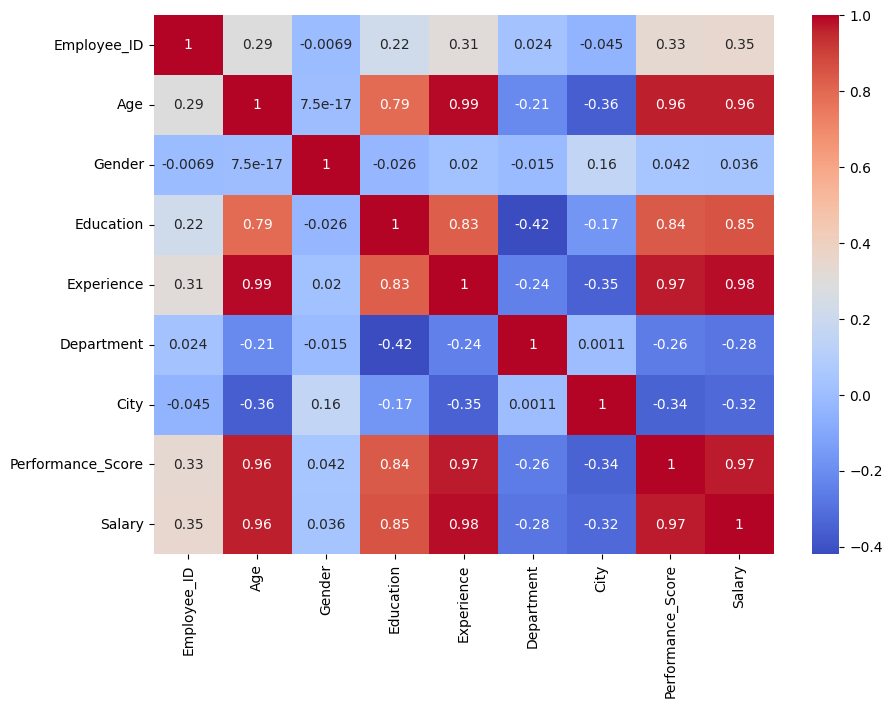

In [14]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True),
annot=True,
cmap="coolwarm")

plt.show()

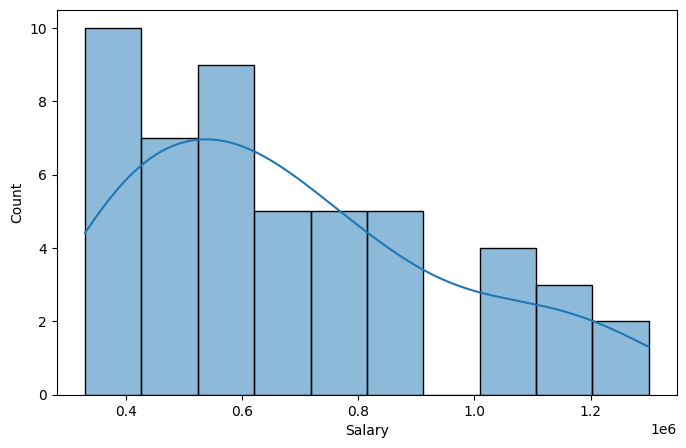

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Salary"],bins=10,kde=True)

plt.show()

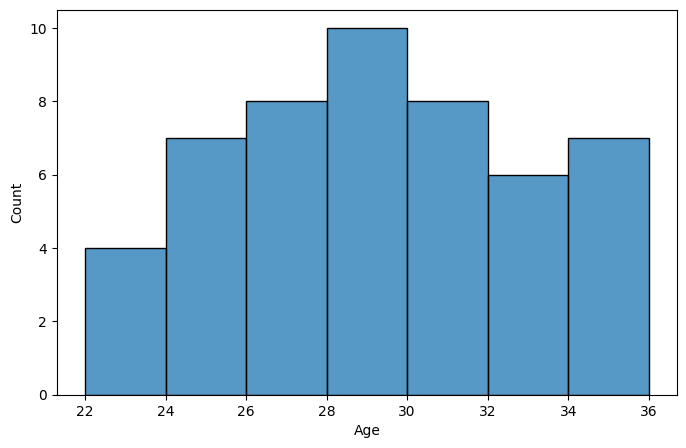

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"])

plt.show()

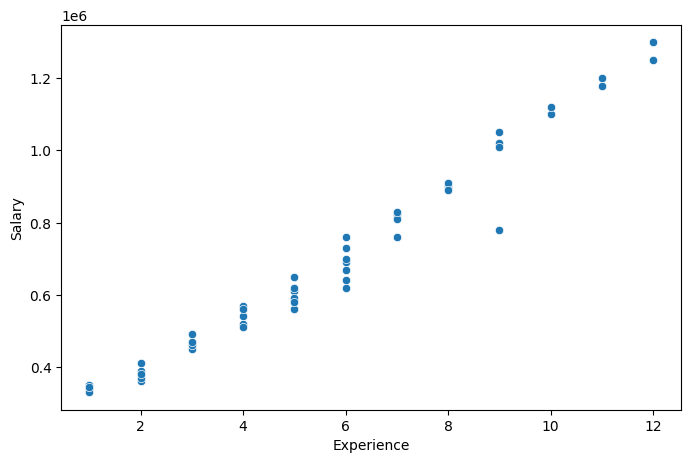

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Experience",
y="Salary",
data=df)

plt.show()

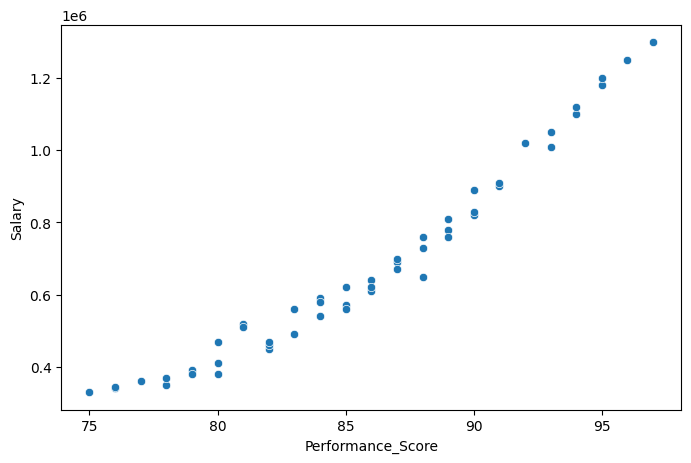

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Performance_Score",
y="Salary",
data=df)

plt.show()

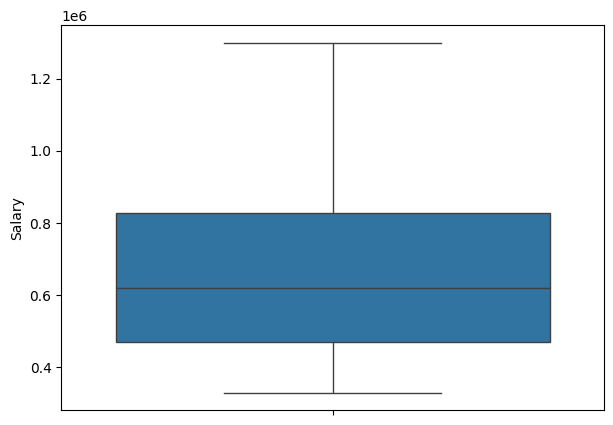

In [19]:
plt.figure(figsize=(7,5))

sns.boxplot(y=df["Salary"])

plt.show()

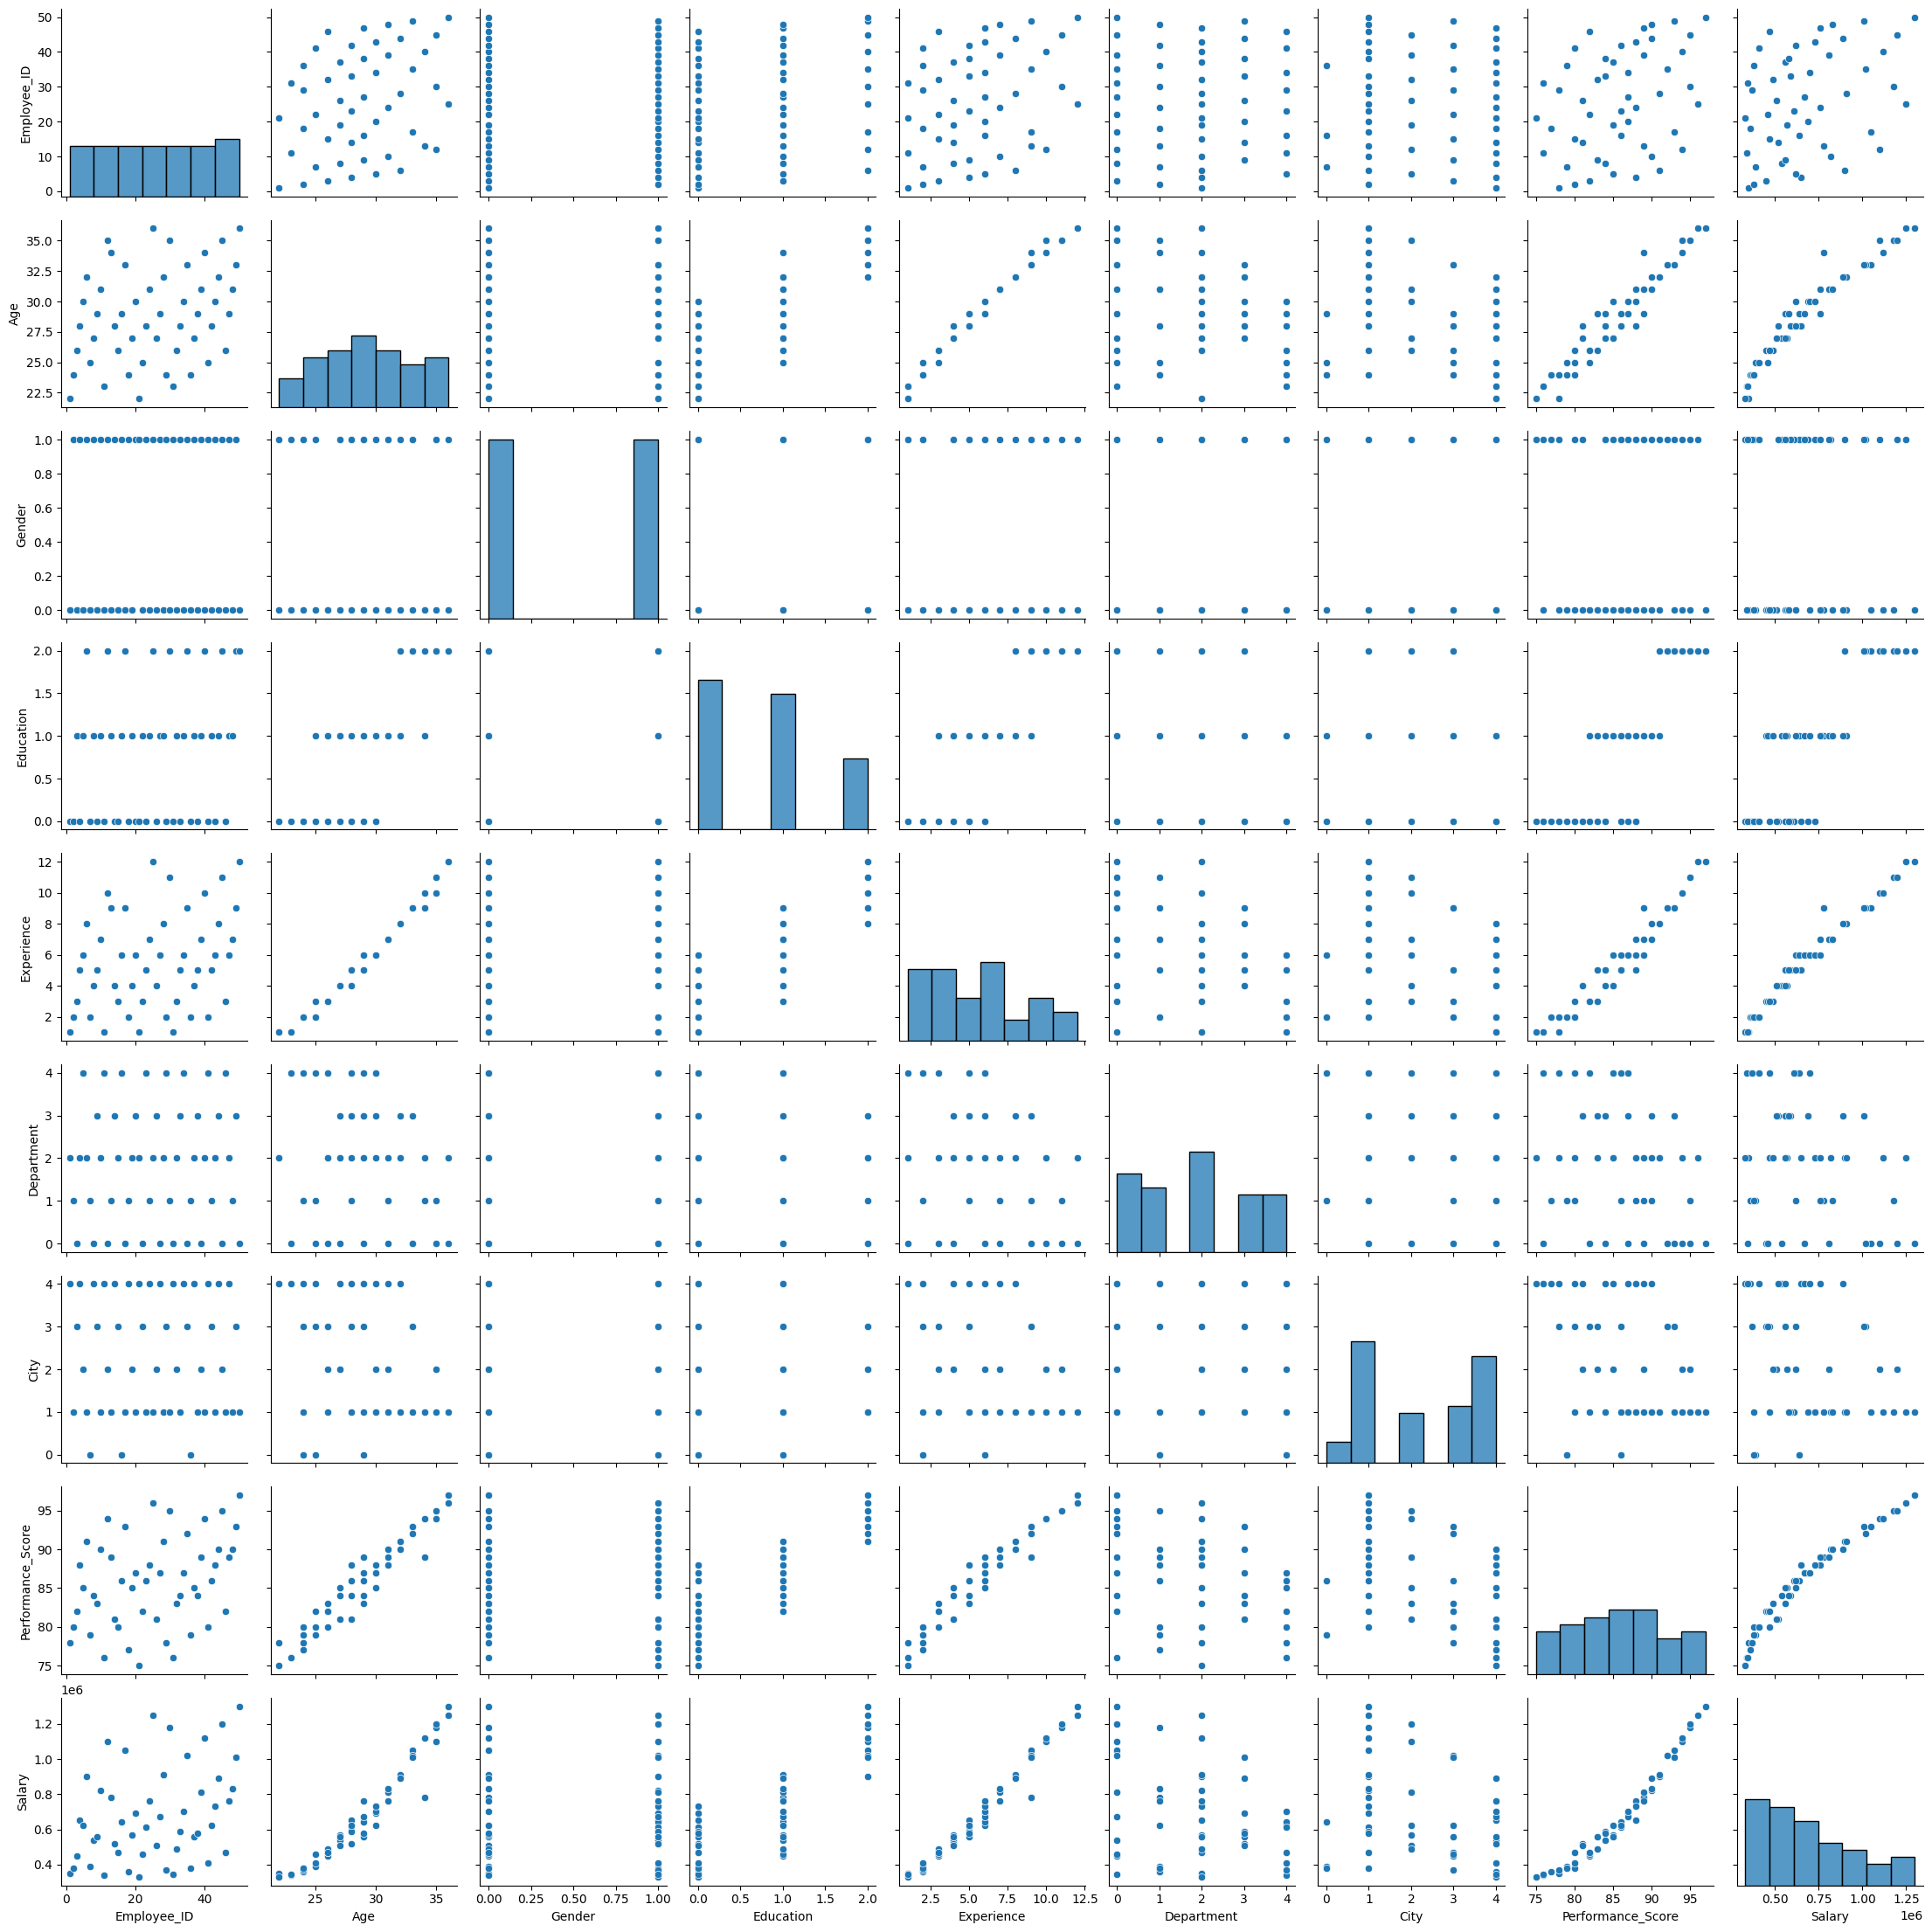

In [20]:
sns.pairplot(df)

In [21]:
X=df.drop("Salary",axis=1)

y=df["Salary"]

In [22]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [23]:
model=LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [24]:
prediction=model.predict(X_test)

prediction

array([ 467935.3528426 , 1084687.30228296,  300292.20615271,
        456243.21319814,  370049.69401371, 1010405.73170899,
        757094.49408775,  508124.84561419,  619889.89343309,
        679592.01211599])

In [25]:
mean_absolute_error(y_test,prediction)

28556.48810369554

In [26]:
mean_squared_error(y_test,prediction)

1483761013.10798

In [27]:
np.sqrt(mean_squared_error(y_test,prediction))

np.float64(38519.61854831873)

In [28]:
r2_score(y_test,prediction)

0.9751672835995167

In [29]:
comparison=pd.DataFrame({
"Actual":y_test,
"Predicted":prediction
})

comparison.head(10)

,Actual,Predicted
13,520000,4.679354e+05
39,1120000,1.084687e+06
30,345000,3.002922e+05
45,470000,4.562432e+05
17,360000,3.700497e+05
48,1010000,1.010406e+06
26,670000,7.570945e+05
25,510000,5.081248e+05
32,590000,6.198899e+05
19,690000,6.795920e+05


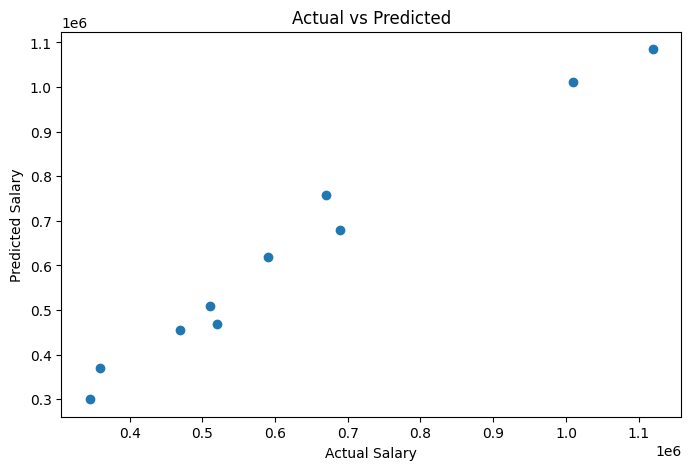

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,prediction)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted")

plt.show()

In [31]:
sample=[[51,27,1,0,3,2,3,88]]

model.predict(sample)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([511995.62515445])